Ryan Dunne
C00263405

Spotify Music Recommendations using K Nearest Neighbour, recommends several similar songs

Dataset used: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

In [1]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

FEATURES = ['danceability','energy','valence','tempo',
            'acousticness','instrumentalness','speechiness'] #Found in the dataset


def build_model(df):
    scaler = StandardScaler()
    X = scaler.fit_transform(df[FEATURES])
    model = NearestNeighbors(n_neighbors=6, metric='euclidean')
    model.fit(X)
    return model, scaler, X


def recommend(song_name, df, model, scaler, X, k=5):
    idx = df[df['track_name'].str.lower() == song_name.lower()].index[0]
    distances, indices = model.kneighbors([X[idx]], n_neighbors=k+1)
    results = df.iloc[indices[0][1:]][['track_name','artists'] + FEATURES]
    results['similarity'] = 1 / (1 + distances[0][1:])
    return results


# Read in data & build model
df = pd.read_csv('data/tracks.csv')
model, scaler, X = build_model(df)


# Songs similar to Blinding Lights by The Weeknd
results = recommend('Blinding Lights', df, model, scaler, X)
print(results[['track_name', 'artists', 'similarity']])

                                     track_name  \
107899  Right By Your Side - Remastered Version   
38541                                  Mob Rule   
444                      You Are the Best Thing   
61565                                    PLAYER   
69744                            Vaanampaadiyin   

                                     artists  similarity  
107899  Eurythmics;Annie Lennox;Dave Stewart    0.798773  
38541                            Bad//Dreems    0.791129  
444                           Ray LaMontagne    0.753149  
61565                              PASSEPIED    0.746527  
69744                                Sujatha    0.746050  


C:\Users\RyanJ\Desktop\DataScience2\KNearestNeighbour\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\RyanJ\Desktop\DataScience2\KNearestNeighbour\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\RyanJ\Desktop\DataScience2\KNearestNeighbour\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\RyanJ\Desktop\DataScience2\KNearestNeighbour\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


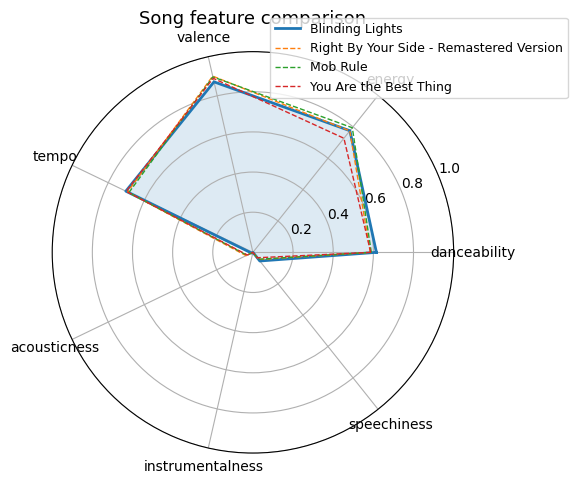

In [2]:
import matplotlib.pyplot as plt
import numpy as np


def spider_chart(query_song, results, df):
    from sklearn.preprocessing import MinMaxScaler
    categories = FEATURES
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    all_rows = pd.concat([df[df['track_name'].str.lower() == query_song.lower()], results])
    scaler = MinMaxScaler()
    scaler.fit(df[FEATURES])

    query_row = df[df['track_name'].str.lower() == query_song.lower()].iloc[0]
    query_vals = scaler.transform([query_row[FEATURES]])[0].tolist()
    query_vals += query_vals[:1]
    ax.plot(angles, query_vals, linewidth=2, label=query_row['track_name'])
    ax.fill(angles, query_vals, alpha=0.15)

    for _, row in results.head(3).iterrows():
        vals = scaler.transform([row[FEATURES]])[0].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=1, linestyle='dashed', label=row['track_name'])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=10)
    ax.set_ylim(0, 1)
    ax.set_title('Song feature comparison', size=13, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

    plt.tight_layout()
    plt.savefig('spider_chart.png', dpi=150)
    plt.show()

spider_chart('Blinding Lights', results, df)

In [3]:
#Compares 2 very different songs on a spider chart

song1 = 'Blinding Lights'
song2 = 'Wonderwall'

row1 = df[df['track_name'].str.lower() == song1.lower()].iloc[0]
row2 = df[df['track_name'].str.lower() == song2.lower()].iloc[0]

print(pd.DataFrame([row1[FEATURES], row2[FEATURES]], index=[song1, song2]).round(3))

                 danceability  energy  valence    tempo  acousticness  \
Blinding Lights         0.606   0.775    0.867  171.011         0.008   
Wonderwall              0.700   0.705    0.521   99.970         0.148   

                 instrumentalness  speechiness  
Blinding Lights             0.000        0.053  
Wonderwall                  0.034        0.041  


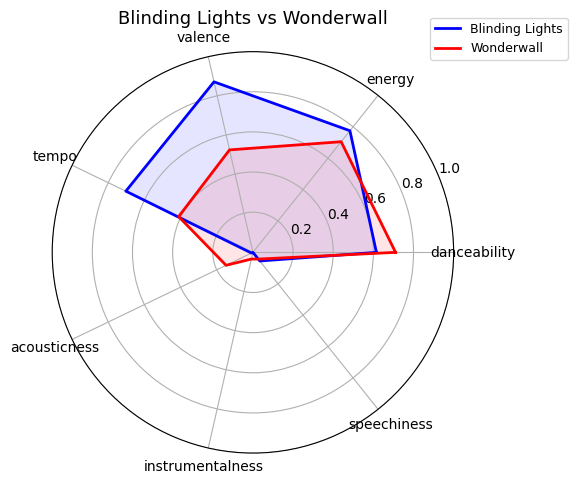

In [4]:
from sklearn.preprocessing import MinMaxScaler

song1 = 'Blinding Lights'
song2 = 'Wonderwall'

results1 = recommend(song1, df, model, scaler, X)
results2 = recommend(song2, df, model, scaler, X)

scaler2 = MinMaxScaler()
scaler2.fit(df[FEATURES])

N = len(FEATURES)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for song, color in [(song1, 'blue'), (song2, 'red')]:
    row = df[df['track_name'].str.lower() == song.lower()].iloc[0]
    vals = scaler2.transform(pd.DataFrame([row[FEATURES]], columns=FEATURES))[0].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, label=song, color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(FEATURES, size=10)
ax.set_ylim(0, 1)
ax.set_title('Blinding Lights vs Wonderwall', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150)
plt.show()